# Joint Baseline Strategy Diagnostics

Run HAPPO through `scripts/diagnose_joint_happo.py` and heuristic approaches through `scripts/diagnose_joint_baseline_strategies.py`, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the same core joint performance metrics used for model comparison:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std
- scout, confirmation, confidence, and coverage AUC
- time to 100%, 80%, and 50% confirmation recall
- scout-to-confirm latency

Edit the strategy settings in the first code cell. If `FILELIST` is empty, the notebook checks one expected JSON per strategy and runs only the missing diagnostics, with up to `MAX_PARALLEL_RUNS` approaches running concurrently. There is no communication-dropout sweep. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.


In [ ]:
# Baseline comparison configuration. Set CKPT to a HAPPO models directory when you want
# the heuristic baselines to reuse that checkpoint's scenario settings.

MODLABEL = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10'
CKPT = "results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099

# One diagnostic is produced for each strategy. This is not a dropout sweep.
STRATEGIES = ['happo', 'ant_colony', 'lawnmower']
COMMS_DROPOUT = 0.0

NSURVIVORS_OBS = 10
NSURVIVORS_MIN = 10
NSURVIVORS_MAX = 10

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False
# Use 1 for sequential execution; increase carefully because each diagnostic is CPU intensive.
MAX_PARALLEL_RUNS = 1

# Optional extra CLI arguments for the selected HAPPO/baseline diagnostic command.
# Examples: ['--disable-fire'], ['--enable-fire'], ['--n-uavs', '3'].
EXTRA_DIAGNOSTIC_ARGS = []

# Optional: provide existing JSON outputs to skip all diagnostic execution.
FILELIST = []
# FILELIST = [
#   'outputs/baseline_comparison/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json',
#   'outputs/baseline_comparison/ant_colony_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json',
#   'outputs/baseline_comparison/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json',
#   'outputs/baseline_comparison/random_walk_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json',
# ]

# Optional display labels for FILELIST entries. Leave empty to derive labels from metadata.
LABELS = []


In [2]:
import json
import shlex

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omnisearch_plotting as plot
import diagnostics

HAPPO_SCRIPT = Path('scripts/diagnose_joint_happo.py')
BASELINE_SCRIPT = Path('scripts/diagnose_joint_baseline_strategies.py')
CWD = Path.cwd().resolve()
if all((CWD / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD
elif all((CWD.parent / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'baseline_comparison'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'

STRATEGY_LABELS = {
    'happo': 'OmniSearch RL',
    'ant_colony': 'ACO',
    'lawnmower': 'Lawnmower',
    'random_walk': 'Random Walk',
    'random_action': 'Random Action',
    'highest_confidence': 'Highest Confidence',
}


In [3]:
if len(STRATEGIES) != len(set(STRATEGIES)):
    raise ValueError('STRATEGIES contains duplicates')
if int(MAX_PARALLEL_RUNS) < 1:
    raise ValueError('MAX_PARALLEL_RUNS must be at least 1')

if FILELIST:
    JSON_FILES = [diagnostics._resolve_json_file(path) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    checkpoint = diagnostics._resolve_checkpoint(CKPT, project_root=PROJECT_ROOT, results_root=RESULTS_ROOT, model_label=MODLABEL)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]
    JSON_FILES = []
    jobs = []

    print('Checkpoint:', checkpoint)
    print('Strategies:', ', '.join(STRATEGIES))
    for index, strategy in enumerate(STRATEGIES, start=1):
        json_output, plots_output = diagnostics._diagnostic_output_paths(strategy, seeds=[SEED_START,SEED_END], model_label=MODLABEL, output_dir=OUTPUT_DIR, comms_dropout=COMMS_DROPOUT)
        JSON_FILES.append(json_output)
        should_run = RUN_DIAGNOSTICS and (
            FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()
        )
        if not should_run:
            print(f'[{index}/{len(STRATEGIES)}] Using existing diagnostics:', json_output)
            continue

        cmd = diagnostics._diagnostic_prefix(strategy, checkpoint, project_root=PROJECT_ROOT, happo_script=HAPPO_SCRIPT, baseline_script=BASELINE_SCRIPT)
        cmd.extend([
            '--steps', str(NSTEPS_PER_EPISODE),
            '--seeds', *seeds,
            '--n-survivors', str(NSURVIVORS_OBS),
            '--active-survivors-min', str(NSURVIVORS_MIN),
            '--active-survivors-max', str(NSURVIVORS_MAX),
            '--json-output', str(json_output),
            '--plots-output', str(plots_output),
        ])
        cmd.extend(str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS)
        log_path = json_output.with_suffix('.log')
        jobs.append((strategy, cmd, log_path))
        print(f'[{index}/{len(STRATEGIES)}] Queued (~9h):', shlex.join(cmd))
        print('Log:', log_path)

    if jobs:
        workers = min(int(MAX_PARALLEL_RUNS), len(jobs))
        print(f'Running {len(jobs)} missing diagnostic(s) with {workers} worker(s).')
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {
                executor.submit(diagnostics._run_diagnostic_job, strategy, cmd, log_path, PROJECT_ROOT): (strategy, log_path, PROJECT_ROOT)
                for strategy, cmd, log_path in jobs
            }
            for future in as_completed(futures):
                strategy, log_path = futures[future]
                future.result()
                print(f'Finished strategy={strategy}; log={log_path}')

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(path) for path in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)


Checkpoint: /Users/aschuetz/Software/capstone/omnisearch/results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models
Strategies: happo, ant_colony, lawnmower, random_walk
[1/4] Using existing diagnostics: /Users/aschuetz/Software/capstone/omnisearch/outputs/baseline_comparison/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[2/4] Using existing diagnostics: /Users/aschuetz/Software/capstone/omnisearch/outputs/baseline_comparison/ant_colony_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[3/4] Using existing diagnostics: /Users/aschuetz/Software/capstone/omnisearch/outputs/baseline_comparison/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[4/4] Using existing diagnostics: /Users/aschuetz/Software/capstone/omnisearch/output

In [4]:
if LABELS and len(LABELS) != len(JSON_FILES):
    raise ValueError(f'LABELS has {len(LABELS)} entries, but JSON_FILES has {len(JSON_FILES)} files')

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = diagnostics._payload_scenario(payload)
    success_rate = diagnostics._success_rate(summary)
    scout_auc_mean, scout_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_scout_steps'),
    )
    confirm_auc_mean, confirm_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_confirm_steps'),
    )
    coverage_auc_mean, coverage_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    confirm_100 = diagnostics._threshold_time(summary, 'recall_100')
    confirm_080 = diagnostics._threshold_time(summary, 'recall_080')
    confirm_050 = diagnostics._threshold_time(summary, 'recall_050')
    latency_mean, latency_std = diagnostics._latency_stats(summary)
    uav_path_length_mean, uav_path_length_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_uav_path_length_m',
        'std_uav_path_length_m',
        'uav_path_length_m',
    )
    uav_conf_eff_mean, uav_conf_eff_std = diagnostics._uav_confidence_efficiency_stats(rows, scenario)
    ugv_cost_per_confirm_mean, ugv_cost_per_confirm_std = diagnostics._ugv_cost_per_confirm_stats(rows)
    full_scout_success = diagnostics._mean_std(
        [float(row.get('scout_recall', 0.0) >= 1.0 - 1e-9) for row in rows]
    )[0]
    records.append({
        'file': str(path),
        'label': str(LABELS[file_index]) if LABELS else diagnostics._label_from_payload(path, payload),
        'strategy': diagnostics._strategy_from_payload(path, payload),
        'episodes': diagnostics._summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'scout_recall_mean': diagnostics._summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': diagnostics._summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': diagnostics._summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': diagnostics._summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': diagnostics._success_std(summary, success_rate),
        'success_count': diagnostics._summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': diagnostics._summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': diagnostics._summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': diagnostics._summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': diagnostics._summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
        'confirm_time_100_mean_s': confirm_100['mean'],
        'confirm_time_100_std_s': confirm_100['std'],
        'confirm_time_100_reached_fraction': confirm_100['reached_fraction'],
        'confirm_time_080_mean_s': confirm_080['mean'],
        'confirm_time_080_std_s': confirm_080['std'],
        'confirm_time_080_reached_fraction': confirm_080['reached_fraction'],
        'confirm_time_050_mean_s': confirm_050['mean'],
        'confirm_time_050_std_s': confirm_050['std'],
        'confirm_time_050_reached_fraction': confirm_050['reached_fraction'],
        'scout_to_confirm_latency_mean_s': latency_mean,
        'scout_to_confirm_latency_std_s': latency_std,
        'uav_path_length_mean_m': uav_path_length_mean,
        'uav_path_length_std_m': uav_path_length_std,
        'uav_confidence_efficiency_mean': uav_conf_eff_mean,
        'uav_confidence_efficiency_std': uav_conf_eff_std,
        'full_scout_success_mean': full_scout_success,
        'ugv_cost_per_confirm_mean': ugv_cost_per_confirm_mean,
        'ugv_cost_per_confirm_std': ugv_cost_per_confirm_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics


,file,label,strategy,episodes,scout_recall_mean,scout_recall_std,confirm_recall_mean,confirm_recall_std,success_mean,success_std,...,confirm_time_050_reached_fraction,scout_to_confirm_latency_mean_s,scout_to_confirm_latency_std_s,uav_path_length_mean_m,uav_path_length_std_m,uav_confidence_efficiency_mean,uav_confidence_efficiency_std,full_scout_success_mean,ugv_cost_per_confirm_mean,ugv_cost_per_confirm_std
0,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL,happo,100.0,0.986099,0.059674,0.962218,0.085379,0.80,0.400000,...,1.0,417.553371,267.993664,52921.330349,4893.447372,13.401192,1.056728,0.94,2.300595,0.563787
1,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO,ant_colony,100.0,0.994667,0.027238,0.957397,0.073083,0.72,0.448999,...,1.0,454.505682,305.147012,53629.148029,289.246936,13.484888,0.079393,0.96,1.882242,0.508141
2,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower,lawnmower,100.0,1.000000,0.000000,0.953079,0.075739,0.68,0.466476,...,1.0,442.182077,304.261194,55500.530737,28.187073,13.876221,0.007390,1.00,1.929408,0.535370
3,/Users/aschuetz/Software/capstone/omnisearch/o...,Random Walk,random_walk,100.0,0.989671,0.036120,0.924460,0.091680,0.55,0.497494,...,1.0,422.839470,287.350985,69755.483719,163.623601,17.724447,0.258272,0.92,3.640232,0.965864


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. AUC values are time-integrated performance scores. Confirmation timing values are in minutes and are conditional on episodes that reached the requested confirmation recall threshold; the adjacent reached columns show how many episodes made it that far.


In [5]:
def _pm(mean, std, *, digits=3, suffix=''):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.{digits}f}{suffix}'
    return f'{mean:.{digits}f} +/- {std:.{digits}f}{suffix}'


def _pct(value):
    if pd.isna(value):
        return 'n/a'
    return f'{100.0 * float(value):.0f}%'


compact = pd.DataFrame({
    'label': metrics['label'],
    'episodes': metrics['episodes'].astype('Int64'),
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'confirm 100% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_100_mean_s'] / 60.0, metrics['confirm_time_100_std_s'] / 60.0)
    ],
    'confirm 100% reached': [_pct(value) for value in metrics['confirm_time_100_reached_fraction']],
    'confirm 80% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_080_mean_s'] / 60.0, metrics['confirm_time_080_std_s'] / 60.0)
    ],
    'confirm 80% reached': [_pct(value) for value in metrics['confirm_time_080_reached_fraction']],
    'confirm 50% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_050_mean_s'] / 60.0, metrics['confirm_time_050_std_s'] / 60.0)
    ],
    'confirm 50% reached': [_pct(value) for value in metrics['confirm_time_050_reached_fraction']],
    'scout-to-confirm latency (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['scout_to_confirm_latency_mean_s'] / 60.0, metrics['scout_to_confirm_latency_std_s'] / 60.0)
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
}).set_index('label')

compact


,episodes,scout recall,confirm recall,success,success count,final confidence,final coverage,confirm 100% time (min),confirm 100% reached,confirm 80% time (min),confirm 80% reached,confirm 50% time (min),confirm 50% reached,scout-to-confirm latency (min),scout AUC,confirm AUC,coverage AUC,confidence AUC
label,,,,,,,,,,,,,,,,,,
OmniSearch RL,100,0.986 +/- 0.060,0.962 +/- 0.085,0.800 +/- 0.400,80,0.987 +/- 0.021,0.993 +/- 0.017,20.9 +/- 4.5 min,80%,16.1 +/- 4.0 min,95%,10.6 +/- 2.9 min,100%,7.0 +/- 4.5 min,0.832 +/- 0.079,0.599 +/- 0.083,0.862 +/- 0.015,0.839 +/- 0.017
ACO,100,0.995 +/- 0.027,0.957 +/- 0.073,0.720 +/- 0.449,72,0.994 +/- 0.002,1.000 +/- 0.000,23.1 +/- 3.9 min,72%,18.8 +/- 4.4 min,97%,12.1 +/- 2.9 min,100%,7.6 +/- 5.1 min,0.813 +/- 0.058,0.545 +/- 0.082,0.831 +/- 0.011,0.814 +/- 0.010
Lawnmower,100,1.000 +/- 0.000,0.953 +/- 0.076,0.680 +/- 0.466,68,1.000 +/- 0.000,1.000 +/- 0.000,23.5 +/- 4.1 min,68%,19.8 +/- 4.4 min,98%,12.8 +/- 3.5 min,100%,7.4 +/- 5.1 min,0.791 +/- 0.060,0.527 +/- 0.094,0.806 +/- 0.004,0.792 +/- 0.004
Random Walk,100,0.990 +/- 0.036,0.924 +/- 0.092,0.550 +/- 0.497,55,0.984 +/- 0.014,0.990 +/- 0.012,23.0 +/- 3.9 min,55%,19.4 +/- 4.7 min,91%,11.6 +/- 3.3 min,100%,7.0 +/- 4.8 min,0.787 +/- 0.078,0.538 +/- 0.093,0.804 +/- 0.019,0.780 +/- 0.018


## Plots

The notebook plots the time-integrated AUC metrics first, then a separate confirmation-timing plot. Timing bars are in minutes, so lower is better.


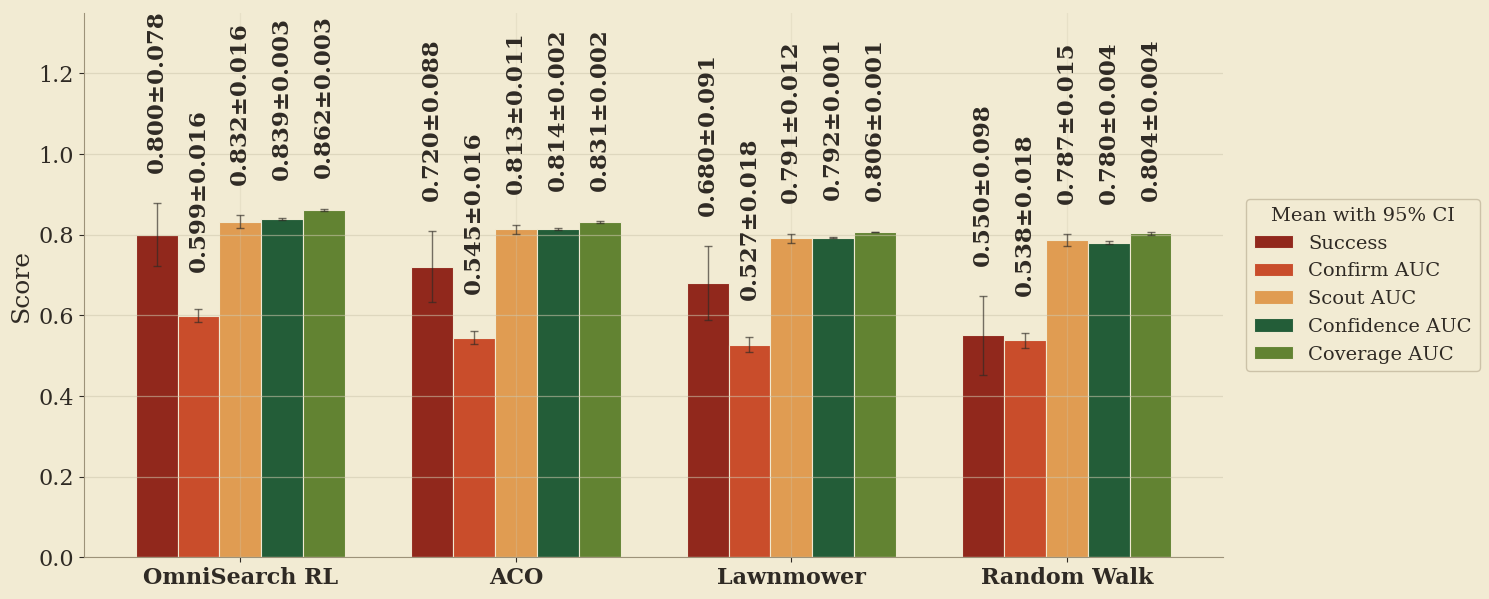

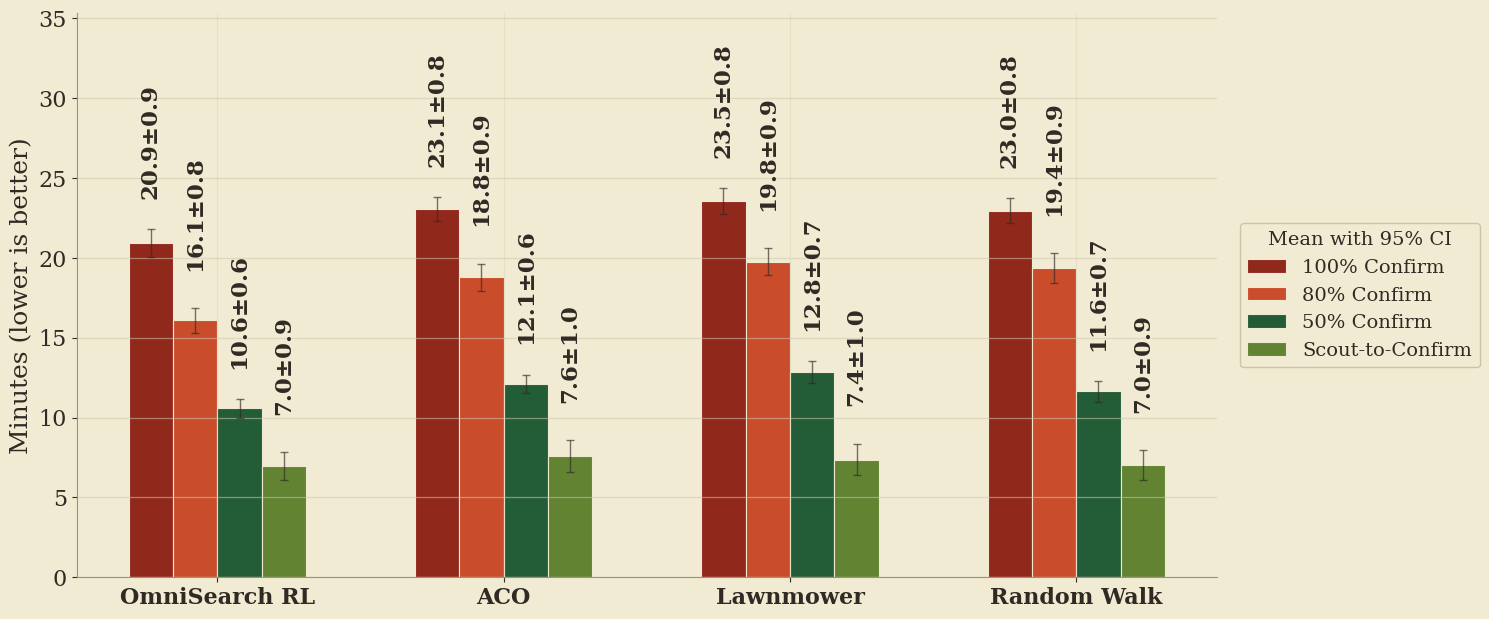

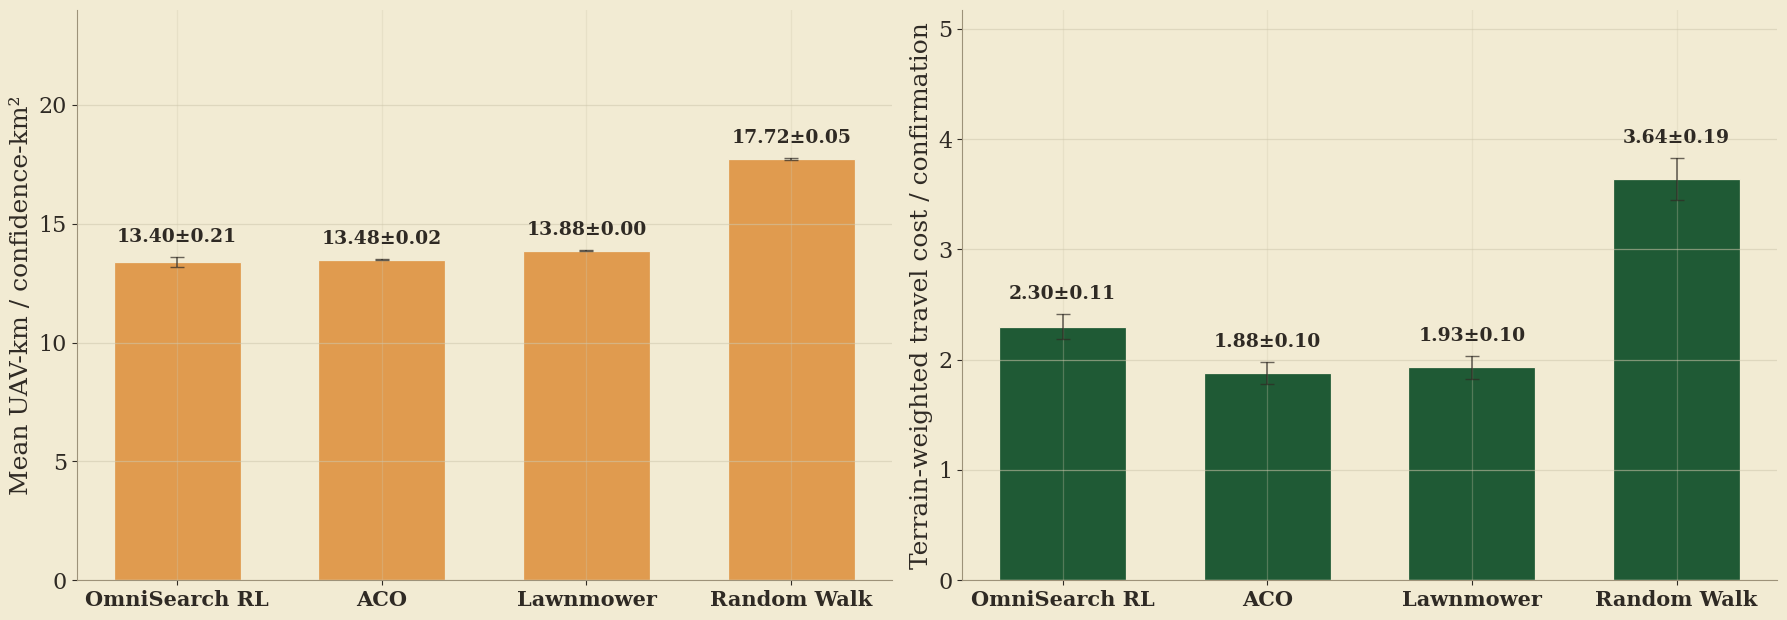

2.300594699106681 0.563787403824717 0.11050233114964454 2.4110970302563253 2.1900923679570363
1.8822419815798186 0.5081410992768567 0.0995956554582639 1.9818376370380826 1.7826463261215546
1.9294080521836396 0.5353704095654935 0.10493260027483674 2.0343406524584764 1.824475451908803
3.640232486273155 0.9658643459311147 0.1893094118024985 3.8295418980756537 3.4509230744706567


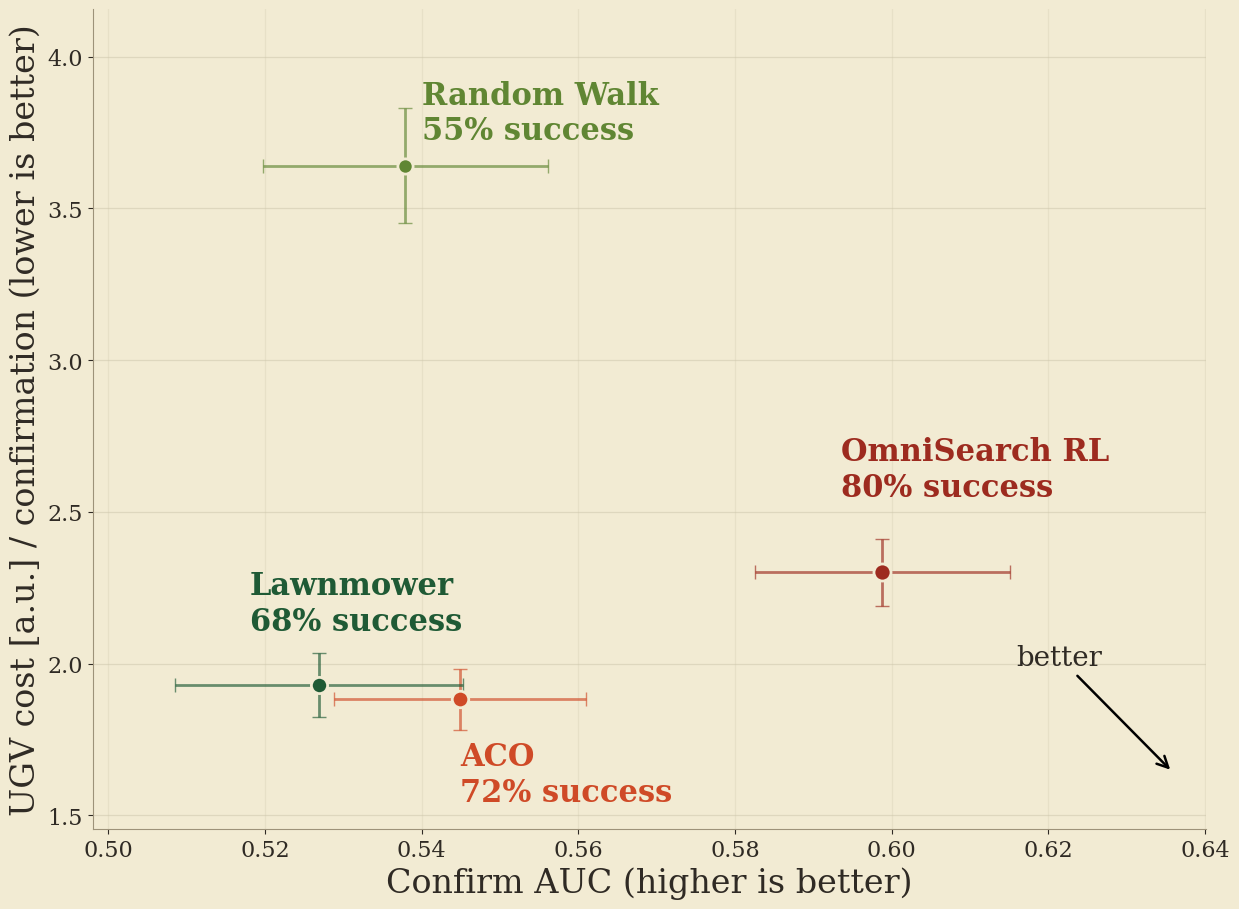

13.40119171054295 1.0567283055884757 0.20711874789534124 13.608310458438291 13.194072962647608
13.484888300820126 0.07939303572645348 0.015561035002384881 13.50044933582251 13.469327265817741
13.876220869351345 0.007389808837226323 0.0014484025320963595 13.877669271883441 13.874772466819248
17.724446636922668 0.25827226088679767 0.05062136313381234 17.77506800005648 17.673825273788857


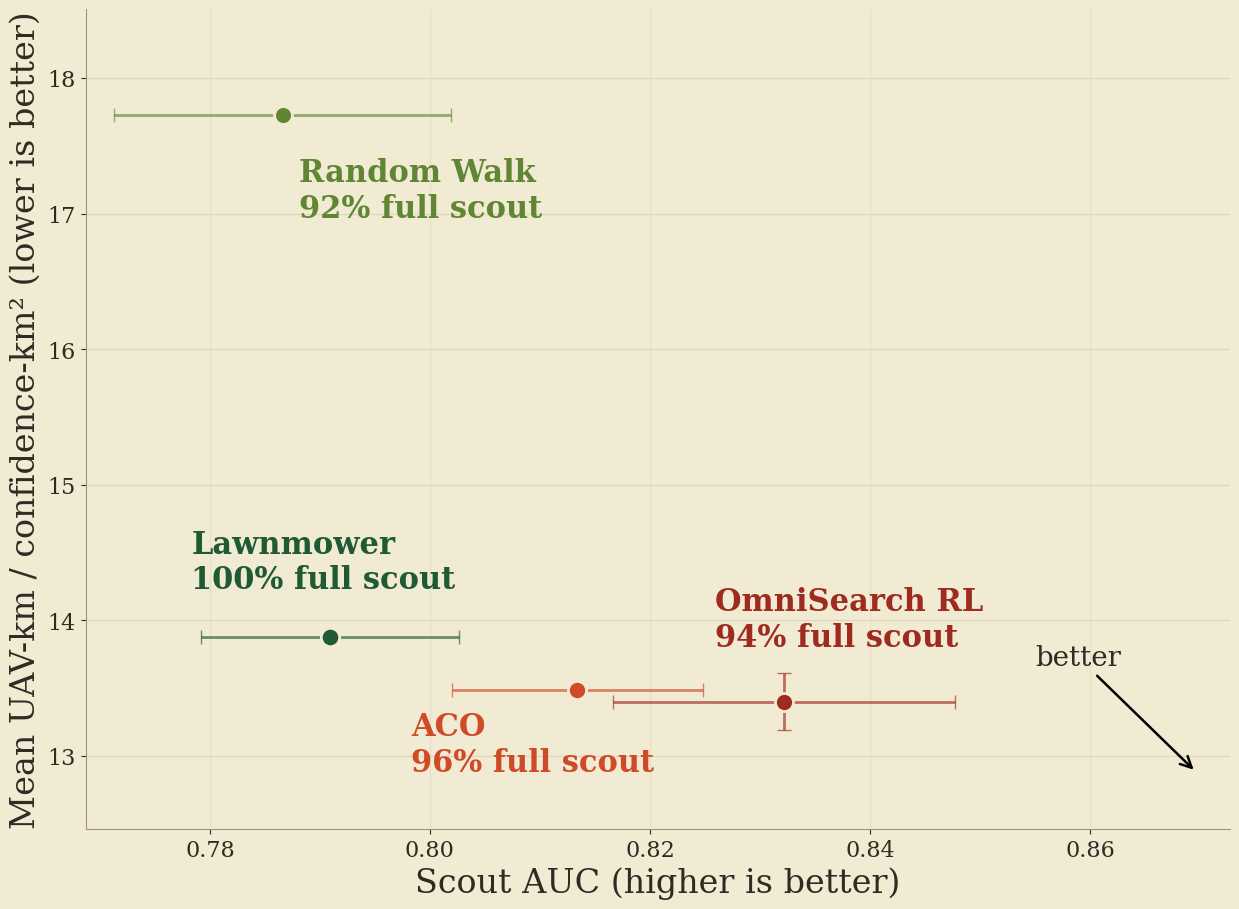

In [6]:
plot_df = metrics.copy().reset_index(drop=True)
for prefix in (
    'confirm_time_100',
    'confirm_time_080',
    'confirm_time_050',
    'scout_to_confirm_latency',
):
    plot_df[f'{prefix}_mean_min'] = pd.to_numeric(plot_df[f'{prefix}_mean_s'], errors='coerce') / 60.0
    plot_df[f'{prefix}_std_min'] = pd.to_numeric(plot_df[f'{prefix}_std_s'], errors='coerce') / 60.0

fig, ax = plt.subplots(figsize=(max(15, len(plot_df) * 2.1), 6.3), facecolor=plot.PAPER_BG)
plot._plot_metrics_bars(
    ax,
    plot_df,
    plot.AUC_METRIC_SPECS,
    title='Success And Time-Integrated Performance (AUC)',
    ylabel='Score',
    y_limit=(0.0, 1.35),
    label_digits=3,
)
fig.tight_layout()
plt.savefig("../outputs/figures/baseline_comparison_peformance.png")
plt.show()

fig, ax = plt.subplots(figsize=(max(15, len(plot_df) * 1.1), 6.3), facecolor=plot.PAPER_BG)
plot._plot_metrics_bars(
    ax,
    plot_df,
    plot.TIME_METRIC_SPECS,
    title='Confirmation Timing',
    ylabel='Minutes (lower is better)',
    mean_suffix='_mean_min',
    std_suffix='_std_min',
    label_suffix='',
    label_digits=1,
)
fig.tight_layout()
plt.savefig("../outputs/figures/baseline_comparison_timing.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6.3), facecolor=plot.PAPER_BG)
plot._plot_single_metric_bars(
    axes[0],
    plot_df,
    mean_column='uav_confidence_efficiency_mean',
    std_column='uav_confidence_efficiency_std',
    scale=1.0,
    title='UAV Confidence Efficiency',
    ylabel='Mean UAV-km / confidence-km²',
    color='#e09b4f',
    label_digits=2,
)
plot._plot_single_metric_bars(
    axes[1],
    plot_df,
    mean_column='ugv_cost_per_confirm_mean',
    std_column='ugv_cost_per_confirm_std',
    scale=1.0,
    title='UGV Confirmation Efficiency',
    ylabel='Terrain-weighted travel cost / confirmation',
    color='#1f5a35',
    label_digits=2,
)
fig.tight_layout()
plt.savefig("../outputs/figures/baseline_comparison_cost.png")
plt.show()


tradeoff_label_offsets = {
    'OmniSearch RL': (-30, 50),
    'ACO': (0, -30),
    'Lawnmower': (-50, 35),
    'Random Walk': (12, 14),
}

fig, ax = plt.subplots(figsize=(12.5, 9.2), facecolor=plot.PAPER_BG)
plot._plot_efficiency_tradeoff(
    ax,
    plot_df,
    x_mean_column='confirm_auc_mean',
    x_std_column='confirm_auc_std',
    y_mean_column='ugv_cost_per_confirm_mean',
    y_std_column='ugv_cost_per_confirm_std',
    success_column='success_mean',
    success_label='success',
    title='Confirmation Speed-Cost Trade-off',
    xlabel='Confirm AUC (higher is better)',
    ylabel='UGV cost [a.u.] / confirmation (lower is better)',
    label_offsets=tradeoff_label_offsets,
)
fig.tight_layout()
plt.savefig("../outputs/figures/baseline_comparison_eff_ugv.png")
plt.show()

uav_tradeoff_offsets = {
    'OmniSearch RL': (-50, 35),
    'ACO': (-120, -15),
    'Lawnmower': (-100, 30),
    'Random Walk': (12, -30),
}
fig, ax = plt.subplots(figsize=(12.5, 9.2), facecolor=plot.PAPER_BG)
plot._plot_efficiency_tradeoff(
    ax,
    plot_df,
    x_mean_column='scout_auc_mean',
    x_std_column='scout_auc_std',
    y_mean_column='uav_confidence_efficiency_mean',
    y_std_column='uav_confidence_efficiency_std',
    success_column='full_scout_success_mean',
    success_label='full scout',
    title='Confidence Speed-Cost Trade-off',
    xlabel='Scout AUC (higher is better)',
    ylabel='Mean UAV-km / confidence-km² (lower is better)',
    label_offsets=uav_tradeoff_offsets,
)
fig.tight_layout()
plt.savefig("../outputs/figures/baseline_comparison_eff_uav.png")
plt.show()


